In [ ]:
import torch
import torch.nn as nn
from torch.optim import AdamW, Adam
from torch.nn import CrossEntropyLoss
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import StepLR,OneCycleLR
!pip install accelerate -U

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 227.6/227.6 kB 12.4 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import re
import os
import time
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

In [ ]:
!pip install transformers
!pip install SentencePiece
!pip install git+https://github.com/PytorchLightning/pytorch-lightning.git@master --upgrade
#!pip install datasets
#from datasets import Dataset

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 99.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 236.8/236.8 kB 31.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 84.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 89.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 14.4 MB/s eta 0:00:00
  Cloning https://github.com/PytorchLightning/pytorch-lightning.git (to revision master) to /tmp/pip-req-build-wdypt2q7
  Running command git clone --filter=blob:none --quiet https://github.com/PytorchLightning/pytorch-lightning.git /tmp/pip-req-build-wdypt2q7
  Resolved https://github.com/PytorchLightning/pytorch-lightning.git to commit 7eca2a2fdd097754834c47f87314fb280cd25d91
  Running command git submodule update --init --recursive -q
  Encountered 31 file(s) that should have been pointers, but weren't:
        .notebooks/course_UvA-DL/01-introduction-to-pytorch.ipynb
        .notebooks/course

In [ ]:
import pytorch_lightning as pl
import transformers
#from transformers import AlbertModel , AlbertTokenizerFast, AlbertTokenizer

In [ ]:
def create_parent_dir():
    '''
    Creates parent directory structures and return their values
    '''
    data_path = './content'
    archive_path = data_path + '/data/'
    if not os.path.exists(data_path):
        print(f"Did not find {data_path} directory, creating one...")
        os.mkdir(data_path)
        os.mkdir(archive_path)
    elif not os.path.exists(archive_path):
        os.mkdir(archive_path)
    else:
        print("Required Parent Directory structure already in place")
    return data_path,archive_path

In [ ]:
create_parent_dir()

Did not find ./content directory, creating one...


('./content', './content/data/')

In [ ]:
!wget https://lp-prod-resources.s3.amazonaws.com/611/65217/2021-06-17-14-38-25/Khilnani_LP_spam_detection_data.csv

--2023-06-28 15:34:54--  https://lp-prod-resources.s3.amazonaws.com/611/65217/2021-06-17-14-38-25/Khilnani_LP_spam_detection_data.csv
Resolving lp-prod-resources.s3.amazonaws.com (lp-prod-resources.s3.amazonaws.com)... 52.92.250.249, 52.92.163.73, 52.218.234.179, ...
Connecting to lp-prod-resources.s3.amazonaws.com (lp-prod-resources.s3.amazonaws.com)|52.92.250.249|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 509852 (498K) [application/octet-stream]
Saving to: ‘Khilnani_LP_spam_detection_data.csv’

Khilnani_LP_spam_de 100%[===================>] 497.90K   715KB/s    in 0.7s    

2023-06-28 15:34:56 (715 KB/s) - ‘Khilnani_LP_spam_detection_data.csv’ saved [509852/509852]



In [ ]:
!ls -l

total 508
drwxr-xr-x 3 root root   4096 Jun 28 15:34 content
-rw-r--r-- 1 root root 509852 Jun 17  2021 Khilnani_LP_spam_detection_data.csv
drwxr-xr-x 1 root root   4096 Jun 26 13:35 sample_data


In [ ]:
lines = 0
with open('./Khilnani_LP_spam_detection_data.csv', 'r') as f:
  for message in f.readlines():
    print(message)
    lines += 1
    if lines>10:
      break

,SMS,label

0,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...

",0

1,"Ok lar... Joking wif u oni...

",0

2,"Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's

",1

3,"U dun say so early hor... U c already then say...

",0

4,"Nah I don't think he goes to usf, he lives around here though

",0



In [ ]:
df_spam = pd.read_csv('./Khilnani_LP_spam_detection_data.csv')
df_spam

,Unnamed: 0,SMS,label
0,0,"Go until jurong point, crazy.. Available only ...",0
1,1,Ok lar... Joking wif u oni...\n,0
2,2,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,3,U dun say so early hor... U c already then say...,0
4,4,"Nah I don't think he goes to usf, he lives aro...",0
...,...,...,...
5569,5569,This is the 2nd time we have tried 2 contact u...,1
5570,5570,Will ü b going to esplanade fr home?\n,0
5571,5571,"Pity, * was in mood for that. So...any other s...",0
5572,5572,The guy did some bitching but I acted like i'd...,0


In [ ]:
df_spam.columns

Index(['Unnamed: 0', 'SMS', 'label'], dtype='object')

In [ ]:
df_spam.drop(columns=['Unnamed: 0'], inplace=True)
df_spam

,SMS,label
0,"Go until jurong point, crazy.. Available only ...",0
1,Ok lar... Joking wif u oni...\n,0
2,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,U dun say so early hor... U c already then say...,0
4,"Nah I don't think he goes to usf, he lives aro...",0
...,...,...
5569,This is the 2nd time we have tried 2 contact u...,1
5570,Will ü b going to esplanade fr home?\n,0
5571,"Pity, * was in mood for that. So...any other s...",0
5572,The guy did some bitching but I acted like i'd...,0


In [ ]:
df_spam.label.value_counts()

0    4827
1     747
Name: label, dtype: int64

In [ ]:
df_spam['SMS'] = df_spam['SMS'].apply(lambda x: x.lower())

In [ ]:
df_spam

,SMS,label
0,"go until jurong point, crazy.. available only ...",0
1,ok lar... joking wif u oni...\n,0
2,free entry in 2 a wkly comp to win fa cup fina...,1
3,u dun say so early hor... u c already then say...,0
4,"nah i don't think he goes to usf, he lives aro...",0
...,...,...
5569,this is the 2nd time we have tried 2 contact u...,1
5570,will ü b going to esplanade fr home?\n,0
5571,"pity, * was in mood for that. so...any other s...",0
5572,the guy did some bitching but i acted like i'd...,0


In [ ]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
stopwords = nltk.corpus.stopwords.words('english')

In [ ]:
type(stopwords), len(stopwords)

(list, 179)

In [ ]:
df_spam['SMS'] = df_spam['SMS'].apply(lambda x: " ".join([word for word in x.split() if word not in stopwords]))

In [ ]:
df_spam['SMS'] = df_spam['SMS'].apply(lambda x: re.sub(r'[^\w\s]', '', x))

In [ ]:
df_spam['SMS']

0       go jurong point crazy available bugis n great ...
1                                 ok lar joking wif u oni
2       free entry 2 wkly comp win fa cup final tkts 2...
3                     u dun say early hor u c already say
4                  nah think goes usf lives around though
                              ...                        
5569    2nd time tried 2 contact u u 750 pound prize 2...
5570                          ü b going esplanade fr home
5571                    pity  mood that soany suggestions
5572    guy bitching acted like id interested buying s...
5573                                       rofl true name
Name: SMS, Length: 5574, dtype: object

In [ ]:
df_spam['SMS'].iloc[9]

'mobile 11 months more u r entitled update latest colour mobiles camera free call mobile update co free 08002986030'

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(df_spam['SMS'], df_spam['label'], test_size=0.1, shuffle=True, random_state=42, stratify=df_spam['label'])

In [ ]:
len(X_train), len(X_val)

(5016, 558)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.1, shuffle=True, random_state=42, stratify=y_train)

In [ ]:
len(X_train), len(X_val), len(X_test), len(y_train), len(y_val), len(y_test)

(4514, 558, 502, 4514, 558, 502)

In [ ]:
X_train, X_val, X_test, y_train, y_val, y_test

(5207    mobile 11mths  update free oranges latest colo...
 3364                                          can im free
 2062    hey  want  crave  miss  need  love you ahmad s...
 1865                                    call ok said call
 498                           told accenture confirm true
                               ...                        
 3515             always chat you fact need money raise me
 260                im parked next mini coming today think
 649                                       prob send email
 4153                                 whats nannys address
 2608              yeah lol luckily starring role like you
 Name: SMS, Length: 4514, dtype: object,
 569     love it daddy make scream pleasure going slap ...
 5103                        nope thats fine might nap tho
 2501                              remember ask alex pizza
 4453     ive told everything stop dont let get dehydrated
 2093    oh love soooo good hear you omg missed much to...
               

In [ ]:
for l in [X_train, X_val, X_test, y_train, y_val, y_test]:
  print(type(l))

<class 'pandas.core.series.Series'>
<class 'pandas.core.series.Series'>
<class 'pandas.core.series.Series'>
<class 'pandas.core.series.Series'>
<class 'pandas.core.series.Series'>
<class 'pandas.core.series.Series'>


In [ ]:
ckpt = 'distilbert-base-uncased'

In [ ]:
from transformers import DistilBertTokenizer, AutoTokenizer

In [ ]:
tokenizer_n = DistilBertTokenizer.from_pretrained(ckpt)
tokenizer = AutoTokenizer.from_pretrained(ckpt)
tokenizer, tokenizer_n

(DistilBertTokenizerFast(name_or_path='distilbert-base-uncased', vocab_size=30522, model_max_length=512, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, clean_up_tokenization_spaces=True),
 DistilBertTokenizer(name_or_path='distilbert-base-uncased', vocab_size=30522, model_max_length=512, is_fast=False, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, clean_up_tokenization_spaces=True))

In [ ]:
tokenizer(X_train.iloc[2])

{'input_ids': [101, 4931, 2215, 13675, 10696, 3335, 2342, 2293, 2017, 10781, 7842, 13089, 2632, 2534, 20784, 102], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

In [ ]:
df_tokens_train = pd.DataFrame()
df_tokens_val = pd.DataFrame()
df_tokens_test = pd.DataFrame()

In [ ]:
df_tokens_train['tokenized'] = X_train.apply(lambda x : tokenizer(x, return_tensors='pt', padding='max_length', truncation=True, max_length=64))

In [ ]:
df_tokens_val['tokenized'] = X_val.apply(lambda x : tokenizer(x, return_tensors='pt', padding='max_length', truncation=True, max_length=64))
df_tokens_test['tokenized'] = X_test.apply(lambda x : tokenizer(x, return_tensors='pt', padding='max_length', truncation=True, max_length=64))

In [ ]:
len(df_tokens_train['tokenized']) == len(X_train), len(df_tokens_val['tokenized']) == len(X_val), len(df_tokens_test['tokenized']) == len(X_test)

(True, True, True)

In [ ]:
df_tokens_train

,tokenized
5207,"[input_ids, attention_mask]"
3364,"[input_ids, attention_mask]"
2062,"[input_ids, attention_mask]"
1865,"[input_ids, attention_mask]"
498,"[input_ids, attention_mask]"
...,...
3515,"[input_ids, attention_mask]"
260,"[input_ids, attention_mask]"
649,"[input_ids, attention_mask]"
4153,"[input_ids, attention_mask]"


In [ ]:
df_tokens_train['tokenized'].iloc[3], df_tokens_val['tokenized'].iloc[3], df_tokens_test['tokenized'].iloc[3]

({'input_ids': tensor([[ 101, 2655, 7929, 2056, 2655,  102,    0,    0,    0,    0,    0,    0,
             0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
             0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
             0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
             0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
             0,    0,    0,    0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
          0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
          0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])},
 {'input_ids': tensor([[  101,  4921,  2063,  2409,  2673,  2644,  2123,  2102,  2292,  2131,
           2139, 10536,  7265,  3064,   102,     0,     0,     0,     0,     0,
              0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
              0,     0,     0,     0,     

In [ ]:
df_spam['len_SMS'] = df_spam['SMS'].apply(lambda x: len(x))

In [ ]:
df_spam['len_SMS'].describe()

count    5574.000000
mean       55.272336
std        42.843400
min         0.000000
25%        23.000000
50%        41.000000
75%        81.000000
max       511.000000
Name: len_SMS, dtype: float64

In [ ]:
df_spam['len_SMS'].quantile(0.9)

115.0

In [ ]:
(df_spam['len_SMS'] > 64).sum()

1814

In [ ]:
df_tokens_train['tokenized'].iloc[3]['input_ids'].shape, df_tokens_train['tokenized'].iloc[3]['attention_mask'].shape

(torch.Size([1, 64]), torch.Size([1, 64]))

In [ ]:
from transformers import DistilBertModel

In [ ]:
test_model = DistilBertModel.from_pretrained(ckpt)
test_model

Some weights of the model checkpoint at distilbert-base-uncased were not used when initializing DistilBertModel: ['vocab_transform.weight', 'vocab_layer_norm.bias', 'vocab_transform.bias', 'vocab_projector.bias', 'vocab_layer_norm.weight']
- This IS expected if you are initializing DistilBertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DistilBertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


DistilBertModel(
  (embeddings): Embeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Transformer(
    (layer): ModuleList(
      (0-5): 6 x TransformerBlock(
        (attention): MultiHeadSelfAttention(
          (dropout): Dropout(p=0.1, inplace=False)
          (q_lin): Linear(in_features=768, out_features=768, bias=True)
          (k_lin): Linear(in_features=768, out_features=768, bias=True)
          (v_lin): Linear(in_features=768, out_features=768, bias=True)
          (out_lin): Linear(in_features=768, out_features=768, bias=True)
        )
        (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (ffn): FFN(
          (dropout): Dropout(p=0.1, inplace=False)
          (lin1): Linear(in_features=768, out_features=3072, bias=True)
          (lin2): Li

In [ ]:
out = test_model(input_ids=df_tokens_train['tokenized'].iloc[3]['input_ids'], attention_mask=df_tokens_train['tokenized'].iloc[3]['attention_mask'])

In [ ]:
out

BaseModelOutput(last_hidden_state=tensor([[[ 0.0316, -0.1836,  0.0965,  ..., -0.1678,  0.1893,  0.3044],
         [ 0.5482, -0.3958,  0.5694,  ...,  0.0064,  0.5644,  0.0753],
         [ 0.0928,  0.2752,  0.8411,  ..., -0.0757,  0.2102,  0.0225],
         ...,
         [ 0.1050, -0.1621,  0.6153,  ...,  0.1218,  0.0270,  0.2077],
         [ 0.1192, -0.1359,  0.5813,  ...,  0.1025,  0.0489,  0.1420],
         [ 0.0968, -0.1392,  0.5429,  ...,  0.1155,  0.0400,  0.1355]]],
       grad_fn=<NativeLayerNormBackward0>), hidden_states=None, attentions=None)

In [ ]:
out.last_hidden_state.shape

torch.Size([1, 64, 768])

In [ ]:
class spam_sms_ds(Dataset):
  def __init__(self, tokens, labels):
    self.tokens = tokens
    self.labels = labels

  def __getitem__(self, idx):
    input_ids = self.tokens.iloc[idx]['input_ids'].squeeze()
    #token_type_ids = self.tokens.iloc[idx]['token_type_ids'].squeeze() #distilbert doesnt recognize this
    attention_mask = self.tokens.iloc[idx]['attention_mask'].squeeze()
    labels = torch.tensor(self.labels.iloc[idx]) #.type(torch.LongTensor)
    return input_ids, attention_mask, labels

  def __len__(self):
    return len(self.labels)

In [ ]:
train_ds = spam_sms_ds(df_tokens_train['tokenized'], y_train)
valid_ds = spam_sms_ds(df_tokens_val['tokenized'], y_val)
test_ds = spam_sms_ds(df_tokens_test['tokenized'], y_test)

In [ ]:
len(train_ds), len(valid_ds), len(test_ds)

(4514, 558, 502)

In [ ]:
train_ds[0][0], valid_ds[0][0], test_ds[0][0]

(tensor([  101,  4684,  2340, 20492,  7898, 10651,  2489,  4589,  2015,  6745,
          6120,  4950,  4684,  2015, 14668,  5353,  4455,  2655,  4684,  2039,
          2094,  2620,  2489, 14876,  2638,  5511,  8889,  2692,  2620, 23499,
         12740,  2475,  1016, 16033, 13876, 18413,   102,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0]),
 tensor([  101,  2293,  2009,  8600,  2191,  6978,  5165,  2183, 14308,  4632,
          5980,   102,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             

In [ ]:
train_dl = DataLoader(train_ds, shuffle=True, batch_size=32, num_workers=os.cpu_count())
valid_dl = DataLoader(valid_ds, shuffle=False, batch_size=32, num_workers=os.cpu_count())
test_dl = DataLoader(test_ds, shuffle=False, batch_size=32, num_workers=os.cpu_count())


In [ ]:
len(train_dl), len(valid_dl), len(train_ds)/32, len(valid_ds)/32, len(test_ds)/32, len(test_dl)

(142, 18, 141.0625, 17.4375, 15.6875, 16)

In [ ]:
input_ids, attention_mask, label = next(iter(train_dl))

In [ ]:
input_ids.shape, attention_mask.shape, label.shape

(torch.Size([32, 64]), torch.Size([32, 64]), torch.Size([32]))

In [ ]:
input_ids_val, attention_mask_val, label_val = next(iter(valid_dl))

In [ ]:
input_ids_val.shape, attention_mask_val.shape, label_val.shape

(torch.Size([32, 64]), torch.Size([32, 64]), torch.Size([32]))

In [ ]:
input_ids_test, attention_mask_test, label_test = next(iter(test_dl))

In [ ]:
input_ids_test.shape, attention_mask_test.shape, label_test.shape

(torch.Size([32, 64]), torch.Size([32, 64]), torch.Size([32]))

In [ ]:
test_model(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state.shape

torch.Size([32, 64, 768])

In [ ]:
test_model(input_ids=input_ids_val, attention_mask=attention_mask_val).last_hidden_state.shape

torch.Size([32, 64, 768])

In [ ]:
test_model(input_ids=input_ids_test, attention_mask=attention_mask_test).last_hidden_state.shape

torch.Size([32, 64, 768])

In [ ]:
class distil_spam_model(torch.nn.Module):
  def __init__(self, embed_size, ckpt, num_labels):
    super().__init__()

    self.checkpoint = ckpt
    self.basemodel = DistilBertModel.from_pretrained(self.checkpoint)
    self.flatten = nn.Flatten()
    self.classifier = nn.Sequential(
        nn.Linear(embed_size, embed_size, bias=False),
        nn.BatchNorm1d(embed_size),
        nn.ReLU(inplace=True),
        nn.Dropout(0.4),
        nn.Linear(embed_size, num_labels)
    )

  def forward(self, input_tokens, attention_tokens):

    x = self.basemodel(input_ids=input_tokens, attention_mask=attention_tokens)
    x = self.flatten(x.last_hidden_state[:,0,:])
    x = self.classifier(x)

    return x

In [ ]:
embed_size = 768
ckpt = 'distilbert-base-uncased'
num_labels = 2
model = distil_spam_model(embed_size,ckpt,num_labels)

Some weights of the model checkpoint at distilbert-base-uncased were not used when initializing DistilBertModel: ['vocab_transform.weight', 'vocab_layer_norm.bias', 'vocab_transform.bias', 'vocab_projector.bias', 'vocab_layer_norm.weight']
- This IS expected if you are initializing DistilBertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DistilBertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [ ]:
model

distil_spam_model(
  (basemodel): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): MultiHeadSelfAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)
            (lin1): 

In [ ]:
out=model(input_ids, attention_mask)

In [ ]:
out.shape

torch.Size([32, 2])

In [ ]:
class Training():
    def __init__(self, model, optimizer, loss_fn, epochs, batch_size, train_gen, valid_gen, test_gen,
                len_train_ds, len_valid_ds, len_test_ds, device, labels_cat, oclr_sched=None, oclr=False, early_stop=True, patience=4):
        super().__init__()
        self.model = model.to(device)
        self.optimizer = optimizer
        self.loss_fn = loss_fn
        self.epochs = epochs
        self.batch_size = batch_size
        self.train_generator = train_gen
        self.valid_generator = valid_gen
        self.test_generator = test_gen
        self.train_ds_size = len_train_ds
        self.valid_ds_size = len_valid_ds
        self.test_ds_size = len_test_ds
        self.train_history = {'loss': [], 'accuracy': [], 'f1': [], 'precision': [], 'recall': []}
        self.valid_history = {'loss': [], 'accuracy': [], 'f1': [], 'precision': [], 'recall': [], 'ckpt_name': []}
        self.early_stop_enabled = early_stop
        self.patience_level = patience
        self.device = device
        self.classes = labels_cat
        self.oclr = oclr
        if(self.oclr):
          self.oclr_sched = oclr_sched

    def train_step(self, input_tokens, attention_tokens, train_label):
        self.model.train()
        output = self.model(input_tokens, attention_tokens)
        loss_value = self.loss_fn(output, train_label)
        self.optimizer.zero_grad()
        loss_value.backward()
        self.optimizer.step()
        if(self.oclr):
          self.oclr_sched.step()
        return output, loss_value  ## To be updated

    def test_step(self, input_tokens, attention_tokens, validation_label):
        self.model.eval()
        with torch.inference_mode():
            val_output = self.model(input_tokens, attention_tokens)
            loss_value = self.loss_fn(val_output, validation_label)
        return val_output, loss_value ## To be updated



    def train(self, df):
        ds_len = self.train_ds_size
        gen = self.train_generator
        loss_epoch = 0
        accuracy = 0
        avg_epoch_loss = 0
        avg_accuracy = 0

        for input_ids, attention_mask, y_batch in gen:
            y_batch = y_batch.type(torch.LongTensor)
            input_ids, attention_mask, y_batch = input_ids.to(self.device), attention_mask.to(self.device), y_batch.to(self.device)
            output, loss_value = self.train_step(input_ids, attention_mask, y_batch)

            pred_labls = list(np.argmax(output.detach().cpu().numpy(), axis=1))
            temp_df = pd.DataFrame({'orig_label': list(y_batch.detach().cpu().numpy()), 'pred_label': pred_labls})
            df = pd.concat([df, temp_df])
            loss_epoch += loss_value.item()*y_batch.shape[0]
            accuracy += (np.array(pred_labls) == y_batch.detach().cpu().numpy()).sum().item()

        avg_epoch_loss = loss_epoch/ds_len
        avg_accuracy = accuracy/ds_len

        return df, avg_epoch_loss, avg_accuracy

    def test_validate(self,df,valid=True,train=False):
        if(valid):
            ds_len = self.valid_ds_size
            gen = self.valid_generator
        elif(train):
            ds_len = self.train_ds_size
            gen = self.train_generator
        else:
            ds_len = self.test_ds_size
            gen = self.test_generator
        loss_epoch = 0
        accuracy = 0
        avg_epoch_loss = 0
        avg_accuracy = 0

        for input_ids, attention_mask, y_batch in gen:
            y_batch = y_batch.type(torch.LongTensor)
            input_ids, attention_mask, y_batch = input_ids.to(self.device), attention_mask.to(self.device), y_batch.to(self.device)
            output, loss_value = self.test_step(input_ids, attention_mask, y_batch)

            pred_labls = list(np.argmax(output.detach().cpu().numpy(), axis=1))
            temp_df = pd.DataFrame({'orig_label': list(y_batch.detach().cpu().numpy()), 'pred_label': pred_labls})
            df = pd.concat([df, temp_df])
            loss_epoch += loss_value.item()*y_batch.shape[0]
            accuracy += (np.array(pred_labls) == y_batch.detach().cpu().numpy()).sum().item()
            #accuracy += (pred_labls == y_batch).sum().item()

        avg_epoch_loss = loss_epoch/ds_len
        avg_accuracy = accuracy/ds_len

        return df, avg_epoch_loss, avg_accuracy

    def train_model(self):
        for epoch in range(self.epochs):
            start_time = time.time()
            histdf_train = pd.DataFrame({'orig_label': [], 'pred_label': []})
            histdf_val   = pd.DataFrame({'orig_label': [], 'pred_label': []})
            df_train_cm, avg_epoch_train_loss, train_accuracy = self.train(histdf_train)
            df_val_cm, avg_epoch_val_loss, val_accuracy = self.test_validate(histdf_val)

            ##################################################################################
            #Following Code snippets calculate and update metric values
            ##################################################################################

            acc_class_train = self.update_metrics_on_epoch_end(df_train_cm, True, self.train_history, avg_epoch_train_loss, train_accuracy)
            acc_class_valid = self.update_metrics_on_epoch_end(df_val_cm, False, self.valid_history, avg_epoch_val_loss, val_accuracy)

            #Code for earlystopping ####
            la = self.valid_history['accuracy']
            if(self.early_stop_enabled):
                if (len(la) > 10):
                    exit_train_loop = self.early_stopping(self.patience_level)
                    if(exit_train_loop):
                        return self.train_history, self.valid_history

            ##Code for saving checkpoints
            if ((la[-1] >= 0.7) and (len(la) > 1)):
                if(la[-1] > max(la[0:-1])):
                    self.save_checkpoint(epoch, la[-1])
            elif ((la[-1] >= 0.7) and (len(la) == 1)):
                self.save_checkpoint(epoch, la[-1])
            torch.cuda.empty_cache()
            print(f'Epoch : {epoch}, Train Loss: {avg_epoch_train_loss}, Train Accuracy: {train_accuracy},\n Validation Loss: {avg_epoch_val_loss}, Validation Accuracy: {val_accuracy}')
            print(f'Time taken: {np.round((time.time() - start_time), 4)}')

        print(f'Training completed successfully. Loading best checkpoint weights ...')
        if len(self.valid_history['ckpt_name']) > 0:
            self.model.load_state_dict(torch.load(self.valid_history['ckpt_name'][-1]))
            print(f'Best checkpoint weights loaded : {self.valid_history["ckpt_name"][-1]}')
        else:
            print("Ouch !! seems like you dont have any checkpoints saved matching criteria specified in logic. Please excuse !")

        return acc_class_train, acc_class_valid


    def update_metrics_on_epoch_end(self, df_cm, train, ds_dict, loss, accuracy):
        f1, precision, recall, recall_list = self.calc_rec_prec_f1(df_cm, train) #Move this to line above once f1 logic is fixed
        ds_dict['loss'].append(loss)
        ds_dict['accuracy'].append(accuracy)
        ds_dict['f1'].append(f1)
        ds_dict['precision'].append(precision)
        ds_dict['recall'].append(recall)
        return recall_list

    def calc_rec_prec_f1(self, df, train):
        print_string = "Training Confusion Matrix" if train else "Validation Confusion Matrix"
        cm = confusion_matrix(df['orig_label'], df['pred_label'])
        print(f'{print_string} \n {cm}')
        num_class = cm.shape[0]
        if (num_class>2):
            incorrect_pred_list = [i for i in range(num_class)]
            recall_list = [i for i in range(num_class)]
            prec_list = [i for i in range(num_class)]
            total_cm = np.sum(cm)
            class_weight_list = [np.sum(cm[i])/total_cm for i in range(num_class)]
            ### Code for recall
            for i in range(num_class):
                recall = cm[i,i]/np.sum(cm[i])
                recall_list[i] = recall

            ## Code for incorrect predictions
            for i in range(num_class):
                val_in = [k for k in range(num_class)]
                val_in.remove(i)
                incorrect_pred = 0
                for j in val_in:
                    incorrect_pred += cm[i,j]
                    incorrect_pred_list[i] = incorrect_pred

            ## Code for precision
            for i in range(num_class):
                val_in = [k for k in range(num_class)]
                val_in.remove(i)
                total_incorrect_preds=0
                for j in val_in:
                    total_incorrect_preds += incorrect_pred_list[j]
                    prec_list[i] = cm[i,i]/(total_incorrect_preds+cm[i,i])

            ## code for cum precision
            precision =np.sum(np.array(prec_list)*np.array(class_weight_list))
            #Code for cum recall
            recall = np.sum(np.array(recall_list)*np.array(class_weight_list))
            ## Code for F1
            ##f1 = 2*precision*recall/(precision+recall)

        else:
            tn, fp, fn, tp = confusion_matrix(df['orig_label'], df['pred_label']).ravel()
            precision = tp/(tp+fp)
            recall = tp/(tp+fn)
            f1 = 2*precision*recall/(precision+recall)
            recall_list = None
        f1 = 2*precision*recall/(precision+recall)
        return f1, precision, recall, recall_list

    def early_stopping(self, early_stop_level):
        la = self.valid_history['accuracy']
        exit_train_loop = False
        n = -1
        while n > -(early_stop_level):
            if not (la[n] <= la[n-1]):
                break
            n = n-1
        if abs(n) == early_stop_level:
            print("Validation accuracy has not improved over last 4 epochs, hence invoking early stopping and exiting training process")
            if len(self.valid_history['ckpt_name']) > 0:
                print('Loading Best weights..')
                self.model.load_state_dict(torch.load(self.valid_history['ckpt_name'][-1]))
            else:
                print("Ouch !! seems like you dont have any checkpoints saved matching criteria specified in logic. Please excuse !")
            exit_train_loop = True
        return exit_train_loop

    def save_checkpoint(self, epoch, acc):
        ckpt_path = './content/data/ckpt/'
        if not os.path.exists(ckpt_path):
            os.mkdir(ckpt_path)
        ckpt_name = ckpt_path + 'ckpt_' + "Epoch_" + str(epoch) + "_Acc_" + str(acc) + '.pt'
        torch.save(self.model.state_dict(), ckpt_name)
        self.valid_history['ckpt_name'].append(ckpt_name)
        print(f'Saved Checkpoint : {ckpt_name}')

    def get_test_accuracy(self):
        df = pd.DataFrame({'orig_label': [], 'pred_label': []})
        df_test, avg_test_loss, test_accuracy = self.test_validate(df,False)
        print(f'Test Loss: {avg_test_loss}, Test Accuracy: {test_accuracy}')
        return df_test, avg_test_loss, test_accuracy

    def predict_single(self, image, transforms=True):
        #In case of dicom images, custom function should be defined outside this class and called with training_object.model
        if(transforms):
            image = Image.open(image)
            image = self.test_transforms(image)
        image = torch.unsqueeze(image, dim=0)
        image = image.to(self.device)
        output = self.model(image)
        pred_label = int(np.argmax(output.detach().cpu().numpy(), axis=1))
        print(f'Predicted label for image supplied is : {self.classes[pred_label]}')
        return self.classes[pred_label]

    def pred_image_show(self,images, labels):
        fig, subs = plt.subplots(3,3, figsize=(14,12))
        for i, sub in enumerate(subs.flatten()):
            pred_class = self.predict_single(images[i], False)
            img_array = images[i].numpy()
            img_array[0] = (img_array[0]*self.std[0]+self.mean[0])*255
            img_array[1] = (img_array[1]*self.std[1]+self.mean[1])*255
            img_array[2] = (img_array[2]*self.std[2]+self.mean[2])*255
            img_array = np.transpose(img_array, (1,2,0))
            img_array = Image.fromarray(np.uint8(img_array)).convert('RGB')
            sub.imshow(img_array) #, cmap='gray')
            sub.set_title(f'{pred_class}(Pred) : {self.classes[labels[i]]}(Orig)')

    def plot_metrics(self):
        list = ['accuracy', 'loss', 'f1', 'recall', 'precision']
        for metrics in list:
            x = [i for i in range(len(self.train_history[metrics]))]
            y1 = self.train_history[metrics]
            y2 = self.valid_history[metrics]
            fig, ax = plt.subplots()
            ax.plot(x, y1, label="train_"+metrics)
            ax.plot(x, y2, label="valid_"+metrics)
            plt.suptitle(f'Plot showing {metrics} for Different Epoch Runs')
            ax.legend()
            plt.show()

    def plot_accuracy(self, acc_class_train, acc_class_valid):
        df_train_acc = pd.DataFrame({'class': self.classes, 'accuracy':acc_class_train})
        df_train_acc['train_valid'] = 'train'
        df_valid_acc = pd.DataFrame({'class': self.classes, 'accuracy':acc_class_valid})
        df_valid_acc['train_valid'] = 'valid'
        df_combined = pd.concat([df_train_acc, df_valid_acc], axis=0)
        sns.barplot(data=df_combined, x='class', y='accuracy', hue='train_valid', order=self.classes)
        plt.show()

In [ ]:
embed_size = 768
ckpt = 'distilbert-base-uncased'
num_labels = 2
model = distil_spam_model(embed_size,ckpt,num_labels)
optimizer = Adam(model.parameters(), lr=0.00002)
loss_fn = CrossEntropyLoss()
epochs = 5
batch_size = 32
train_gen = train_dl
valid_gen = valid_dl
test_gen = test_dl
len_train_ds = len(train_ds)
len_valid_ds = len(valid_ds)
len_test_ds = len(test_ds)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
labels_cat = ['NON-SPAM', 'SPAM']

Some weights of the model checkpoint at distilbert-base-uncased were not used when initializing DistilBertModel: ['vocab_transform.weight', 'vocab_layer_norm.bias', 'vocab_transform.bias', 'vocab_projector.bias', 'vocab_layer_norm.weight']
- This IS expected if you are initializing DistilBertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DistilBertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [ ]:
train_obj = Training(model, optimizer, loss_fn, epochs, batch_size, train_gen, valid_gen, test_gen,
                     len_train_ds, len_valid_ds, len_test_ds, device, labels_cat)

In [ ]:
train_obj.__dict__

{'model': distil_spam_model(
   (basemodel): DistilBertModel(
     (embeddings): Embeddings(
       (word_embeddings): Embedding(30522, 768, padding_idx=0)
       (position_embeddings): Embedding(512, 768)
       (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
       (dropout): Dropout(p=0.1, inplace=False)
     )
     (transformer): Transformer(
       (layer): ModuleList(
         (0-5): 6 x TransformerBlock(
           (attention): MultiHeadSelfAttention(
             (dropout): Dropout(p=0.1, inplace=False)
             (q_lin): Linear(in_features=768, out_features=768, bias=True)
             (k_lin): Linear(in_features=768, out_features=768, bias=True)
             (v_lin): Linear(in_features=768, out_features=768, bias=True)
             (out_lin): Linear(in_features=768, out_features=768, bias=True)
           )
           (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
           (ffn): FFN(
             (dropout): Dropout(p=0.1, inpla

In [ ]:
train_acc, valid_acc = train_obj.train_model()

Training Confusion Matrix 
 [[3590  319]
 [  44  561]]
Validation Confusion Matrix 
 [[482   1]
 [ 11  64]]
Saved Checkpoint : ./content/data/ckpt/ckpt_Epoch_0_Acc_0.978494623655914.pt
Epoch : 0, Train Loss: 0.2353133570764331, Train Accuracy: 0.9195835179441737,
 Validation Loss: 0.08941505387372013, Validation Accuracy: 0.978494623655914
Time taken: 27.0501
Training Confusion Matrix 
 [[3882   27]
 [  28  577]]
Validation Confusion Matrix 
 [[482   1]
 [  7  68]]
Saved Checkpoint : ./content/data/ckpt/ckpt_Epoch_1_Acc_0.985663082437276.pt
Epoch : 1, Train Loss: 0.07748334518459238, Train Accuracy: 0.987815684536996,
 Validation Loss: 0.0715457089045035, Validation Accuracy: 0.985663082437276
Time taken: 25.07
Training Confusion Matrix 
 [[3897   12]
 [  23  582]]
Validation Confusion Matrix 
 [[482   1]
 [  8  67]]
Epoch : 2, Train Loss: 0.04827847822305635, Train Accuracy: 0.9922463447053611,
 Validation Loss: 0.06921489722359138, Validation Accuracy: 0.9838709677419355
Time taken: 

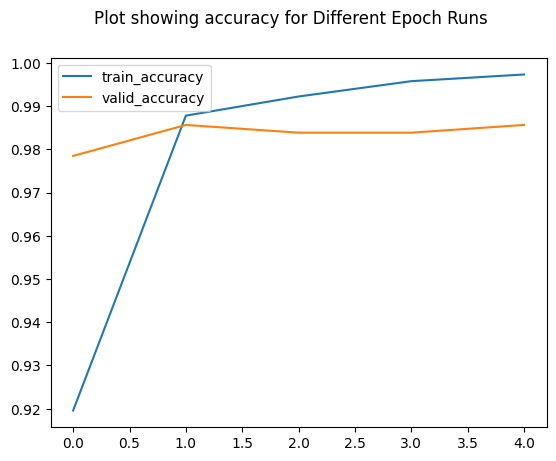

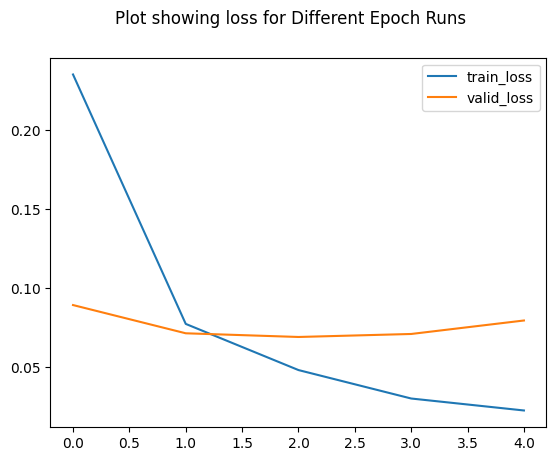

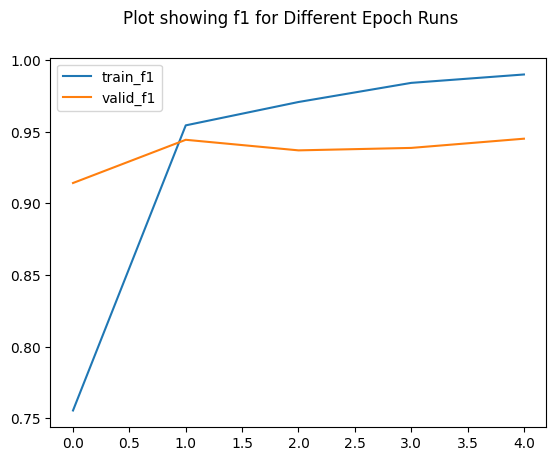

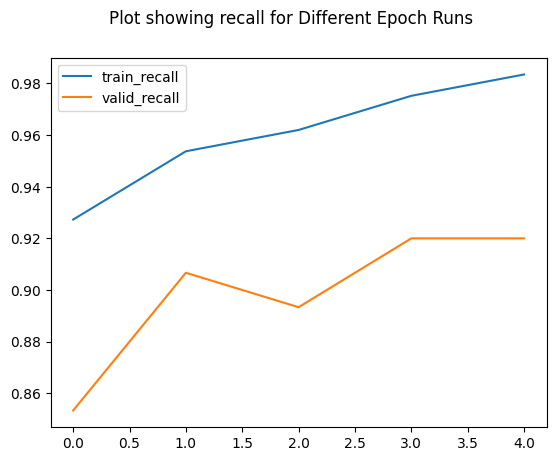

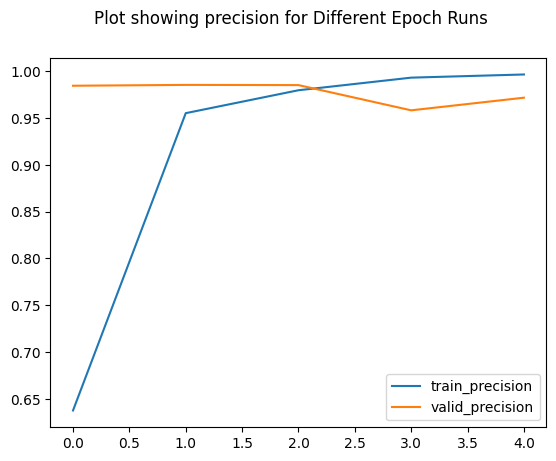

In [ ]:
train_obj.plot_metrics()

In [ ]:
df_test, avg_test_loss, test_accuracy = train_obj.get_test_accuracy()

Test Loss: 0.05822070787449282, Test Accuracy: 0.9900398406374502


In [ ]:
cm = confusion_matrix(df_test['orig_label'], df_test['pred_label'])
print(f'Confusion Matrix: \n {cm}  \n Recall: {cm[1,1]/(cm[1,0]+cm[1,1])}')

Confusion Matrix: 
 [[433   2]
 [  3  64]]  
 Recall: 0.9552238805970149
